# Tu reloj ya predice diabetes tipo 2

**7.834 pasos al día. 67 latidos por minuto. 7,5 horas de sueño.** Tu smartwatch ya mide todo eso. Un modelo de inteligencia artificial entrenado con 1.165 personas puede usar esos números — junto con análisis de sangre rutinarios — para estimar tu riesgo de resistencia a la insulina. Y la resistencia a la insulina es el paso previo a la diabetes tipo 2.

---

**Paper:** Dunn, J. et al. (2026). "Insulin resistance prediction from wearables and routine blood biomarkers." *Nature*.
**DOI:** [10.1038/s41586-026-10179-2](https://doi.org/10.1038/s41586-026-10179-2)
**Video:** [Ver en YouTube](https://youtube.com/watch?v=vB7xqNB999g)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-20-reloj-predice-diabetes/notebook.ipynb)

## ¿Qué hicieron?

El estudio WEAR-ME reclutó 1.165 participantes en Estados Unidos (636 mujeres, 505 hombres, 24 otros). Cada persona llevó un smartwatch durante semanas y se hizo análisis de sangre completos, incluyendo insulina y glucosa en ayunas.

Con esos datos, calcularon el HOMA-IR — un índice que mide la resistencia a la insulina (homeostatic model assessment of insulin resistance). Un HOMA-IR ≥ 2,9 indica resistencia a la insulina, el paso previo a la diabetes tipo 2. Luego entrenaron redes neuronales para predecir ese HOMA-IR usando solo los datos del reloj y análisis de sangre rutinarios.

Veamos los datos de los 1.165 participantes.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
HOMA_CUTOFF = 2.9            # Umbral clínico de resistencia a la insulina
AUROC_MODELO = 0.80          # Rendimiento reportado del modelo
FUENTE = 'Fuente: Dunn et al. (2026), Nature | Datos: GitHub Google-Health/consumer-health-research'
COLOR_IS = '#059669'          # Insulin Sensitive (verde)
COLOR_IMPAIRED = '#D97706'    # Impaired (ámbar)
COLOR_IR = '#DC2626'          # Insulin Resistant (rojo)
COLOR_DATOS = '#2563EB'

# ── Imports y estilo ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os, urllib.request

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# ── Datos ──
if not os.path.exists('datos/participantes.csv'):
    os.makedirs('datos', exist_ok=True)
    urllib.request.urlretrieve(
        f'{BASE}/papers/2026-03-20-reloj-predice-diabetes/datos/participantes.csv',
        'datos/participantes.csv')

df = pd.read_csv('datos/participantes.csv')

# Grupos
is_group = df[df['homa_ir_status'] == 'is']
impaired = df[df['homa_ir_status'] == 'impaired_ir']
ir_group = df[df['homa_ir_status'] == 'ir']

print(f"Participantes: {len(df)} ({len(is_group)} sensibles, {len(impaired)} alterados, {len(ir_group)} resistentes)")
print(f"Edad: {df['age'].mean():.0f} ± {df['age'].std():.0f} años (rango {df['age'].min():.0f}-{df['age'].max():.0f})")
print(f"BMI: mediana {df['bmi'].median():.0f} kg/m²")
print(f"HOMA-IR: mediana {df['homa_ir'].median():.2f} (cut-off clínico = {HOMA_CUTOFF})")

Participantes: 1165 (275 sensibles, 587 alterados, 303 resistentes)
Edad: 47 ± 13 años (rango 21-80)
BMI: mediana 28 kg/m²
HOMA-IR: mediana 1.81 (cut-off clínico = 2.9)


## ¿Cuánta resistencia a la insulina hay en la cohorte?

Aquí está.

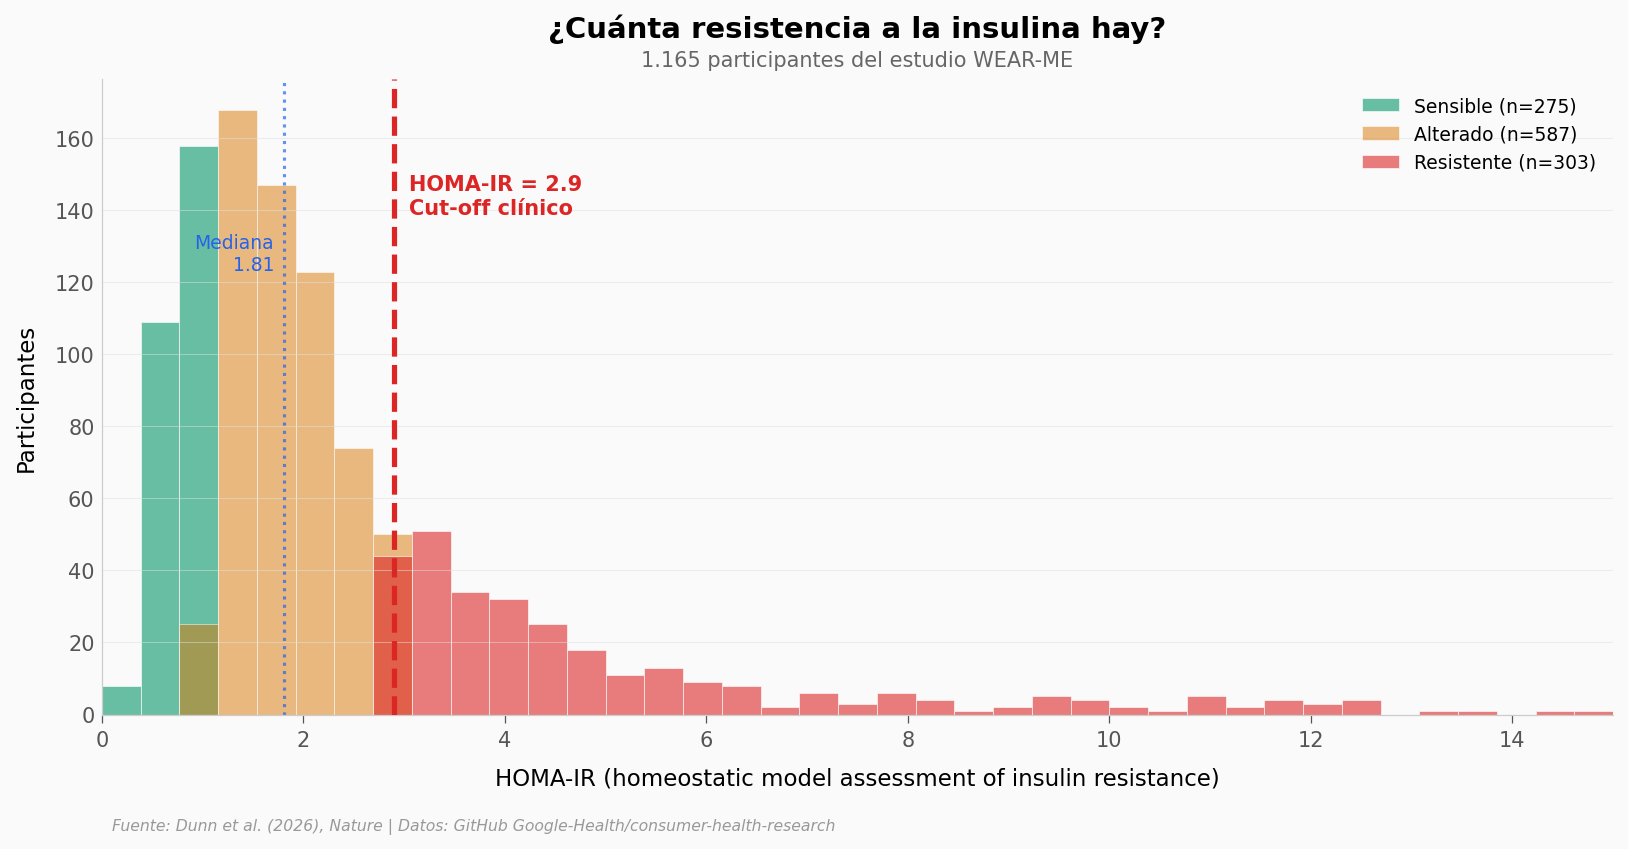

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Histograma por grupo
bins = np.linspace(0, 15, 40)
ax.hist(is_group['homa_ir'], bins=bins, color=COLOR_IS, alpha=0.6,
        edgecolor='white', linewidth=0.5, label=f'Sensible (n={len(is_group)})')
ax.hist(impaired['homa_ir'], bins=bins, color=COLOR_IMPAIRED, alpha=0.5,
        edgecolor='white', linewidth=0.5, label=f'Alterado (n={len(impaired)})')
ax.hist(ir_group['homa_ir'], bins=bins, color=COLOR_IR, alpha=0.6,
        edgecolor='white', linewidth=0.5, label=f'Resistente (n={len(ir_group)})')

# Cut-off clínico
y_max = ax.get_ylim()[1]
ax.axvline(x=HOMA_CUTOFF, color=COLOR_IR, linewidth=2.5, linestyle='--', zorder=5)
ax.text(HOMA_CUTOFF + 0.15, y_max * 0.85, f'HOMA-IR = {HOMA_CUTOFF}\nCut-off clínico',
        fontsize=10, color=COLOR_IR, fontweight='bold', va='top')

# Mediana
med = df['homa_ir'].median()
ax.axvline(x=med, color=COLOR_DATOS, linewidth=1.5, linestyle=':', alpha=0.7)
ax.text(med - 0.1, y_max * 0.7, f'Mediana\n{med:.2f}', fontsize=9,
        color=COLOR_DATOS, ha='right')

ax.set_xlabel('HOMA-IR (homeostatic model assessment of insulin resistance)', fontsize=11)
ax.set_ylabel('Participantes', fontsize=11)
ax.set_title('¿Cuánta resistencia a la insulina hay?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'{len(df):,} participantes del estudio WEAR-ME'.replace(',', '.'),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.set_xlim(0, 15)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_homa_ir.png', dpi=200, bbox_inches='tight')
plt.show()

La mayoría tiene HOMA-IR bajo (buena sensibilidad a la insulina), pero se estira hacia la derecha — algunos llegan hasta un HOMA-IR de 15. La línea roja marca el cut-off clínico de 2,9: todo lo que queda a la derecha indica resistencia a la insulina.

El 26% de la cohorte (303 personas) cruza ese umbral. Otro 50% (587) está en zona "alterada" — no son resistentes, pero tampoco están en el rango óptimo. Solo el 24% (275) tiene sensibilidad normal a la insulina.

## ¿Qué dice tu reloj sobre la resistencia a la insulina?

Comparemos los datos del wearable entre quienes son sensibles a la insulina y quienes son resistentes.

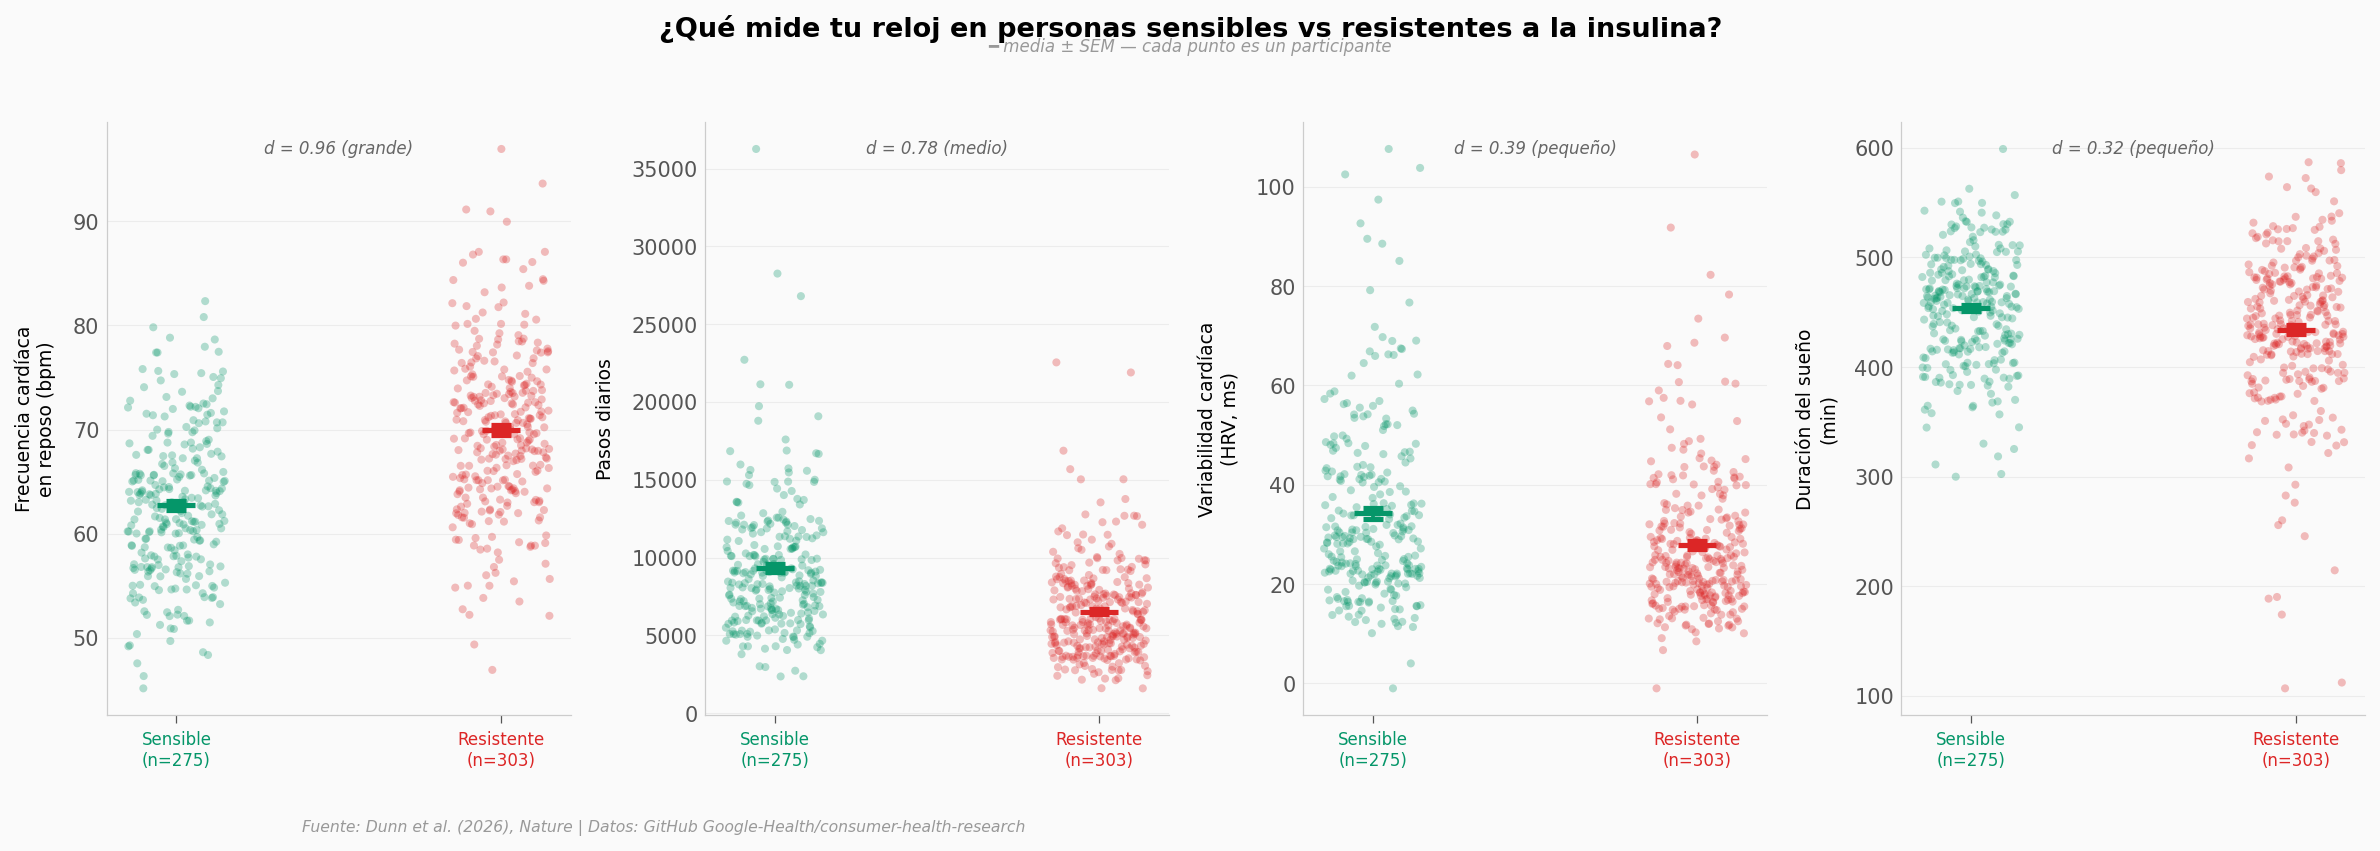

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

features = [
    ('RHR_FreeLiving_mean', 'Frecuencia cardíaca\nen reposo (bpm)', 'bpm'),
    ('STEPS_Daily_mean', 'Pasos diarios', 'pasos/día'),
    ('HRV_FreeLiving_mean', 'Variabilidad cardíaca\n(HRV, ms)', 'ms'),
    ('SLEEP_Duration_mean', 'Duración del sueño\n(min)', 'min'),
]

groups_data = [
    ('is', COLOR_IS, 'Sensible'),
    ('ir', COLOR_IR, 'Resistente'),
]

np.random.seed(42)
for ax_i, (col, ylabel, unit) in enumerate(features):
    ax = axes[ax_i]
    positions = [0, 1]
    
    for pos, (grp, color, label) in enumerate(groups_data):
        sub = df[df['homa_ir_status'] == grp][col].dropna()
        n = len(sub)
        x_strip = np.linspace(pos - 0.15, pos + 0.15, n)
        np.random.shuffle(x_strip)
        ax.scatter(x_strip, sub, color=color, s=15, alpha=0.3,
                   edgecolors='none', zorder=3)
        mean = sub.mean()
        sem = sub.std() / np.sqrt(n)
        ax.errorbar(pos, mean, yerr=sem, fmt='_', color=color,
                    markersize=18, markeredgewidth=2.5,
                    capsize=5, capthick=1.5, zorder=6)
    
    ax.set_xticks(positions)
    ax.set_xticklabels(['Sensible\n(n=275)', 'Resistente\n(n=303)'], fontsize=8)
    for tick, color in zip(ax.get_xticklabels(), [COLOR_IS, COLOR_IR]):
        tick.set_color(color)
    ax.set_ylabel(ylabel, fontsize=9)

    # Cohen's d
    a = is_group[col].dropna()
    b = ir_group[col].dropna()
    pooled_std = np.sqrt(((len(a)-1)*a.std()**2 + (len(b)-1)*b.std()**2) / (len(a)+len(b)-2))
    d = abs(a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0
    size_label = 'grande' if d > 0.8 else 'medio' if d > 0.5 else 'pequeño'
    ax.text(0.5, 0.97, f'd = {d:.2f} ({size_label})', transform=ax.transAxes,
            fontsize=8, ha='center', va='top', color='#666666', style='italic')

fig.suptitle('¿Qué mide tu reloj en personas sensibles vs resistentes a la insulina?',
             fontsize=13, fontweight='bold', y=1.04)
fig.text(0.5, 0.99, '━ media ± SEM — cada punto es un participante',
         ha='center', fontsize=8, color='#999999', style='italic')
plt.tight_layout()
fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/wearables_por_grupo.png', dpi=200, bbox_inches='tight')
plt.show()

En esta cohorte, la frecuencia cardíaca en reposo es la señal más fuerte del wearable: 62,7 bpm en sensibles vs 70,0 bpm en resistentes (d=0,96, efecto grande). Los pasos diarios también separan bien: 9.348 vs 6.527 pasos (d=0,78). La variabilidad cardíaca y el sueño muestran diferencias más modestas.

## ¿Y si combinamos el reloj con los análisis de sangre?

El modelo del paper combina wearables + biomarcadores y alcanza un AUROC de 0,80. ¿Qué variable predice mejor la resistencia?

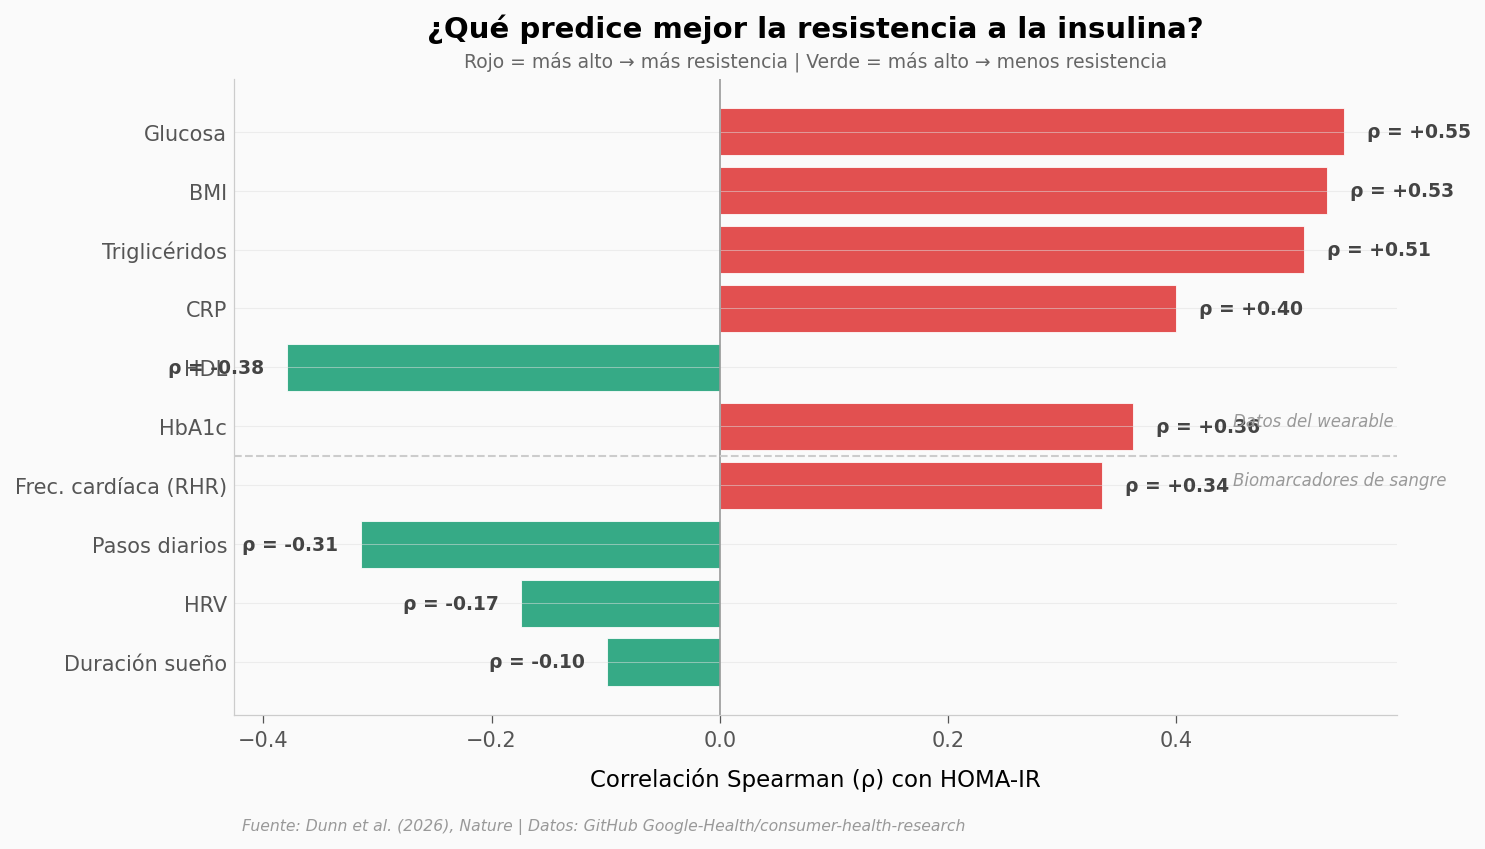


⚠️ Insulina (ρ = 0,99) omitida — HOMA-IR se calcula a partir de insulina y glucosa


In [4]:
# Correlaciones Spearman con HOMA-IR
features_corr = {
    'BMI': 'bmi',
    'Glucosa': 'glucose',
    'HbA1c': 'hba1c',
    'Triglicéridos': 'triglycerides',
    'CRP': 'crp',
    'HDL': 'hdl',
    'Frec. cardíaca (RHR)': 'RHR_FreeLiving_mean',
    'Pasos diarios': 'STEPS_Daily_mean',
    'HRV': 'HRV_FreeLiving_mean',
    'Duración sueño': 'SLEEP_Duration_mean',
}

rhos = {}
for label, col in features_corr.items():
    valid = df[[col, 'homa_ir']].dropna()
    rho, p = stats.spearmanr(valid[col], valid['homa_ir'])
    rhos[label] = rho

# Ordenar por valor absoluto
sorted_feats = sorted(rhos.items(), key=lambda x: abs(x[1]), reverse=True)
labels = [f[0] for f in sorted_feats]
values = [f[1] for f in sorted_feats]
colors = [COLOR_IR if v > 0 else COLOR_IS for v in values]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(range(len(labels)), values, color=colors, alpha=0.8, edgecolor='white')

for i, (label, val) in enumerate(sorted_feats):
    ax.text(val + (0.02 if val > 0 else -0.02), i,
            f'ρ = {val:+.2f}', fontsize=9, va='center',
            ha='left' if val > 0 else 'right',
            color='#444444', fontweight='bold')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.axvline(x=0, color='#999999', linewidth=0.8)
ax.set_xlabel('Correlación Spearman (ρ) con HOMA-IR', fontsize=11)
ax.set_title('¿Qué predice mejor la resistencia a la insulina?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Rojo = más alto → más resistencia | Verde = más alto → menos resistencia',
        transform=ax.transAxes, fontsize=9, color='#666666', ha='center')

# Separador wearables vs sangre
ax.axhline(y=5.5, color='#CCCCCC', linewidth=1, linestyle='--')
ax.text(0.45, 6.0, 'Biomarcadores de sangre', fontsize=8, color='#999999', style='italic')
ax.text(0.45, 5.0, 'Datos del wearable', fontsize=8, color='#999999', style='italic')

ax.invert_yaxis()
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/correlaciones_homa_ir.png', dpi=200, bbox_inches='tight')
plt.show()

# Nota: insulina omitida porque HOMA-IR se calcula a partir de insulina (ρ ≈ 1, trivial)
print("\n⚠️ Insulina (ρ = 0,99) omitida — HOMA-IR se calcula a partir de insulina y glucosa")

Glucosa lidera las correlaciones (ρ=0,55), seguida de BMI (ρ=0,53) y triglicéridos (ρ=0,51). La insulina fue omitida porque HOMA-IR se calcula directamente a partir de ella (ρ ≈ 1, trivial).

De los datos del wearable, la frecuencia cardíaca en reposo es la señal más fuerte (ρ=0,34) — comparable a la CRP (ρ=0,40), un marcador inflamatorio que requiere análisis de sangre. Los pasos diarios (ρ=-0,31) aportan una señal comparable. El sueño apenas contribuye (ρ=-0,10).

## ¿Cuántos pasos separan a los sensibles de los resistentes?

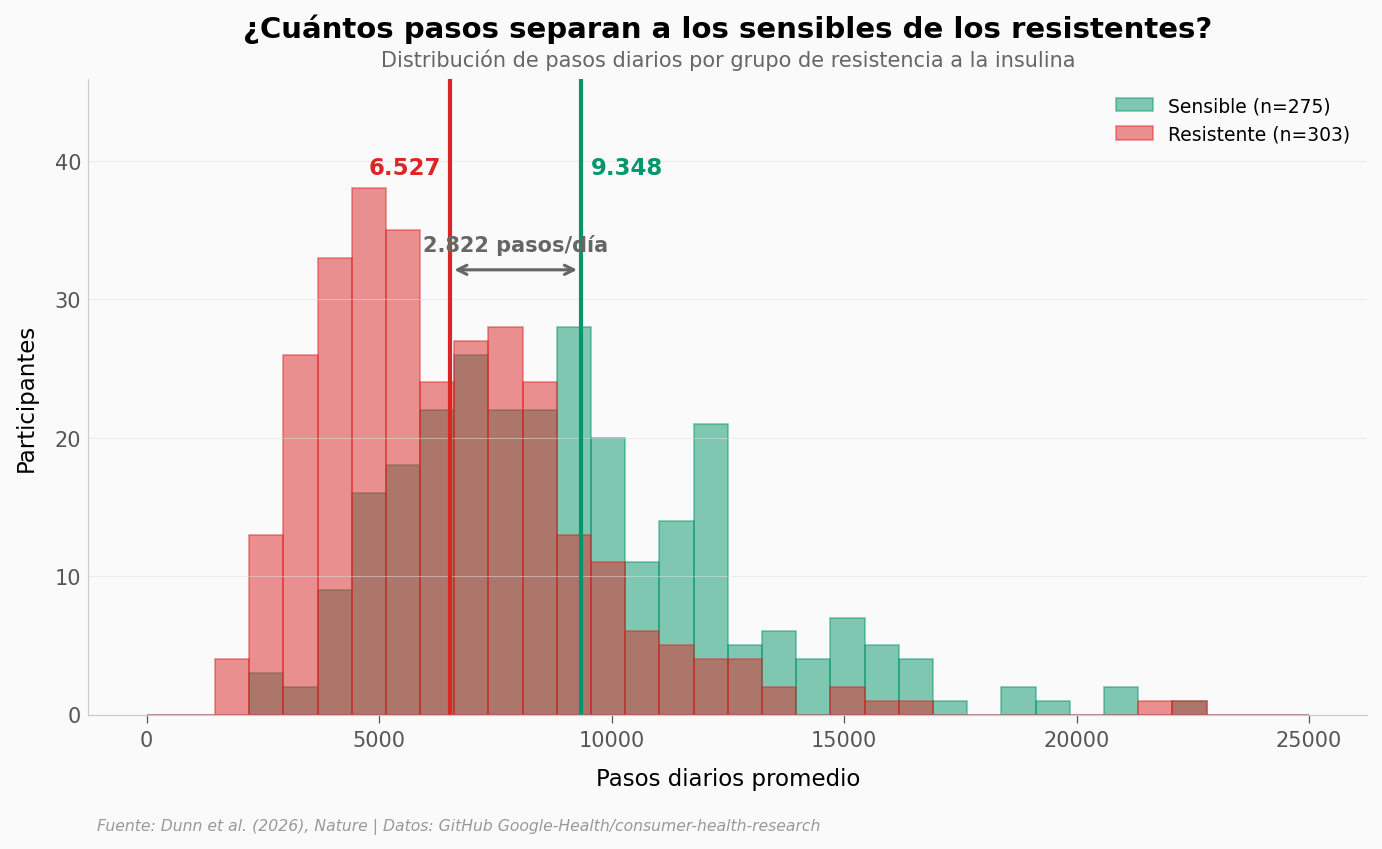

Diferencia: 2.822 pasos/día
Mann-Whitney U: p = 8.15e-22
Cohen's d = 0.78 (efecto medio)


In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

bins = np.linspace(0, 25000, 35)
ax.hist(is_group['STEPS_Daily_mean'], bins=bins, color=COLOR_IS, alpha=0.5,
        edgecolor=COLOR_IS, linewidth=0.8, label=f'Sensible (n={len(is_group)})')
ax.hist(ir_group['STEPS_Daily_mean'], bins=bins, color=COLOR_IR, alpha=0.5,
        edgecolor=COLOR_IR, linewidth=0.8, label=f'Resistente (n={len(ir_group)})')

y_max = ax.get_ylim()[1] * 1.15
ax.set_ylim(0, y_max)

# Medias
mean_is = is_group['STEPS_Daily_mean'].mean()
mean_ir = ir_group['STEPS_Daily_mean'].mean()
ax.axvline(x=mean_is, color=COLOR_IS, linewidth=2, linestyle='-')
ax.axvline(x=mean_ir, color=COLOR_IR, linewidth=2, linestyle='-')

ax.text(mean_is + 200, y_max * 0.85, f'{mean_is:,.0f}'.replace(',', '.'),
        fontsize=11, color=COLOR_IS, fontweight='bold')
ax.text(mean_ir - 200, y_max * 0.85, f'{mean_ir:,.0f}'.replace(',', '.'),
        fontsize=11, color=COLOR_IR, fontweight='bold', ha='right')

# Flecha bidireccional
ax.annotate('', xy=(mean_is, y_max*0.7), xytext=(mean_ir, y_max*0.7),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff = mean_is - mean_ir
ax.text((mean_is + mean_ir)/2, y_max*0.73, f'{diff:,.0f} pasos/día'.replace(',', '.'),
        fontsize=10, color='#666666', ha='center', fontweight='bold')

ax.set_xlabel('Pasos diarios promedio', fontsize=11)
ax.set_ylabel('Participantes', fontsize=11)
ax.set_title('¿Cuántos pasos separan a los sensibles de los resistentes?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Distribución de pasos diarios por grupo de resistencia a la insulina',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/pasos_por_grupo.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadísticas
u, p = stats.mannwhitneyu(is_group['STEPS_Daily_mean'], ir_group['STEPS_Daily_mean'])
pooled = np.sqrt(((len(is_group)-1)*is_group['STEPS_Daily_mean'].std()**2 +
                   (len(ir_group)-1)*ir_group['STEPS_Daily_mean'].std()**2) /
                  (len(is_group)+len(ir_group)-2))
d = abs(mean_is - mean_ir) / pooled
print(f"Diferencia: {diff:,.0f} pasos/día".replace(',', '.'))
print(f"Mann-Whitney U: p = {p:.2e}")
print(f"Cohen's d = {d:.2f} (efecto {'grande' if d > 0.8 else 'medio' if d > 0.5 else 'pequeño'})")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Frecuencia cardíaca en reposo diferencia IS de IR | ✅ | 62,7 vs 70,0 bpm, d=0,96 (grande), p<10⁻²⁵. Efecto clínicamente relevante |
| Pasos diarios diferencian IS de IR | ✅ | 9.348 vs 6.527, d=0,78 (medio), p<10⁻²¹. Diferencia de ~2.800 pasos/día |
| El modelo alcanza AUROC=0,80 | ⚠️ | Reportado en el paper (no reproducible con estos datos — requiere el modelo entrenado). Los datos sí muestran separación clara en las features |
| El sueño predice resistencia a la insulina | ⚠️ | ρ=-0,10 (muy débil), d=0,32 (pequeño). Existe la asociación pero es la señal wearable más débil |
| Glucosa y BMI son los predictores más fuertes | ✅ | Glucosa ρ=0,55, BMI ρ=0,53. Triglicéridos (ρ=0,51) comparable. Consistente con la literatura |

> **Limitaciones:** (1) Estudio observacional — correlación, no causalidad. Más pasos no garantizan menos resistencia. (2) Cohorte de EE.UU., mediana BMI 28 (sobrepeso) — puede no generalizar a otras poblaciones. (3) HOMA-IR es un proxy, no el gold standard (clamp euglicémico). (4) No tenemos el modelo entrenado — solo podemos verificar las features, no el AUROC.

## Ahora tú

1. **¿El efecto es igual en hombres y mujeres?** Filtra `df` por sexo y compara la correlación pasos → HOMA-IR. ¿El wearable predice igual en ambos grupos?

2. **¿Hay un umbral de pasos?** Si graficas HOMA-IR vs pasos, ¿hay un número de pasos a partir del cual el riesgo baja drásticamente? Pista: prueba un scatter con `STEPS_Daily_mean` en X y `homa_ir` en Y, coloreado por BMI.

3. **¿La edad cambia la historia?** Los participantes van de 21 a 80 años. ¿La frecuencia cardíaca en reposo predice igual la resistencia en jóvenes (<40) que en mayores (>60)?

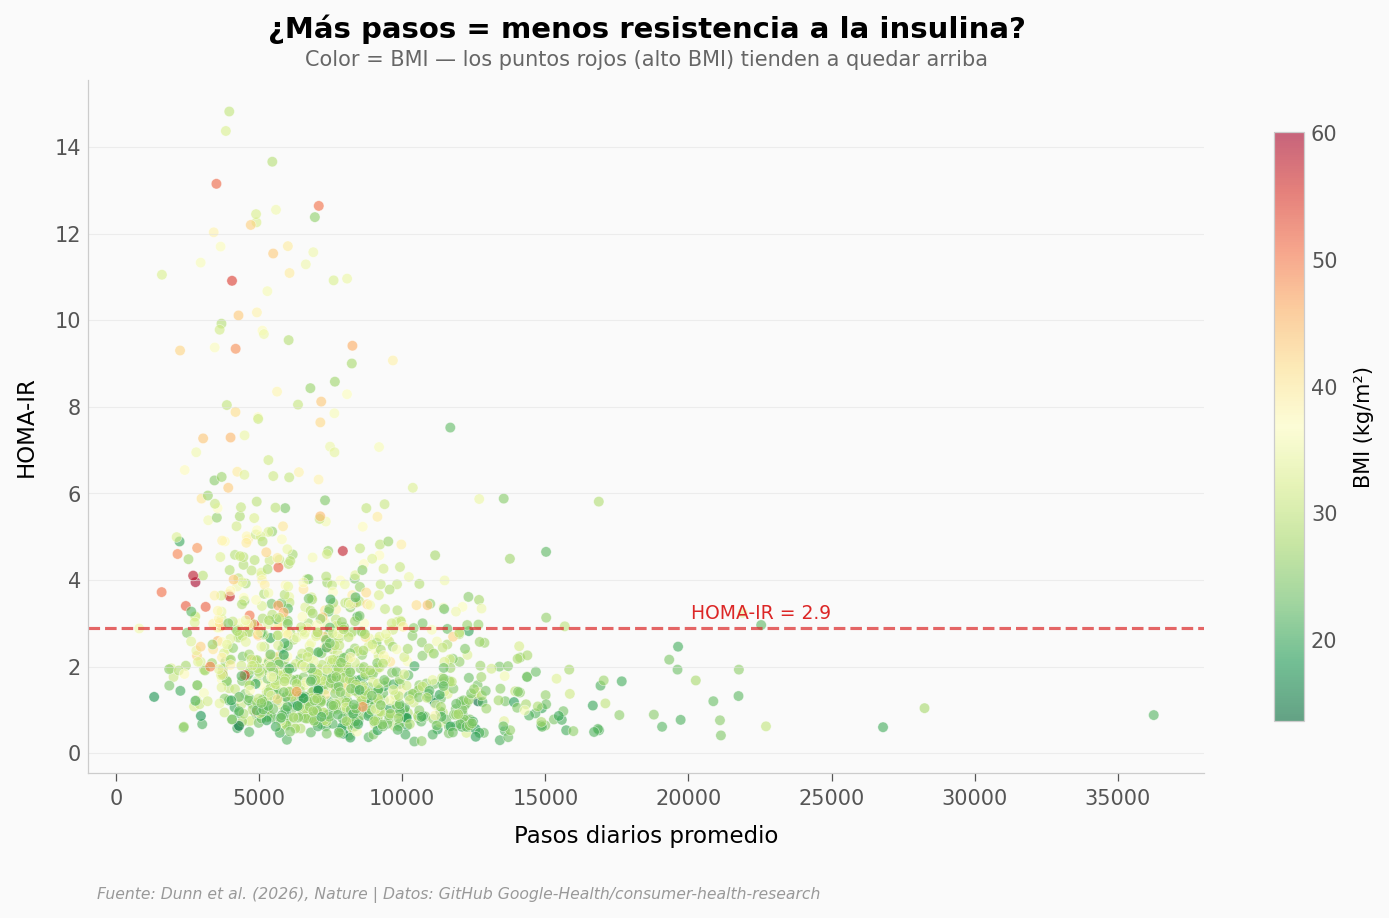

Spearman pasos → HOMA-IR: ρ = -0.315
Spearman parcial (controlando BMI): ρ = -0.193, p = 3.34e-11
→ Los pasos siguen prediciendo HOMA-IR incluso controlando por BMI


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta: ¿Hay un umbral de pasos a partir del cual baja el HOMA-IR?

fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(df['STEPS_Daily_mean'], df['homa_ir'],
                     c=df['bmi'], cmap='RdYlGn_r', s=25, alpha=0.6,
                     edgecolors='white', linewidths=0.3)
cbar = plt.colorbar(scatter, ax=ax, shrink=0.85)
cbar.set_label('BMI (kg/m²)', fontsize=10)

ax.axhline(y=HOMA_CUTOFF, color=COLOR_IR, linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(25000, HOMA_CUTOFF + 0.2, f'HOMA-IR = {HOMA_CUTOFF}', fontsize=9,
        color=COLOR_IR, ha='right')

ax.set_xlabel('Pasos diarios promedio', fontsize=11)
ax.set_ylabel('HOMA-IR', fontsize=11)
ax.set_title('¿Más pasos = menos resistencia a la insulina?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Color = BMI — los puntos rojos (alto BMI) tienden a quedar arriba',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/pasos_vs_homa_ir.png', dpi=200, bbox_inches='tight')
plt.show()

# Correlación parcial (pasos → HOMA-IR controlando por BMI)
from scipy import stats as st
rho_raw, _ = st.spearmanr(df['STEPS_Daily_mean'], df['homa_ir'])
# Residuales de BMI
valid = df[['STEPS_Daily_mean', 'homa_ir', 'bmi']].dropna()
res_steps = valid['STEPS_Daily_mean'] - np.polyval(np.polyfit(valid['bmi'], valid['STEPS_Daily_mean'], 1), valid['bmi'])
res_homa = valid['homa_ir'] - np.polyval(np.polyfit(valid['bmi'], valid['homa_ir'], 1), valid['bmi'])
rho_partial, p_partial = st.spearmanr(res_steps, res_homa)
print(f"Spearman pasos → HOMA-IR: ρ = {rho_raw:.3f}")
print(f"Spearman parcial (controlando BMI): ρ = {rho_partial:.3f}, p = {p_partial:.2e}")
print(f"→ Los pasos siguen prediciendo HOMA-IR incluso controlando por BMI")

---

**Paper:** Dunn, J. et al. (2026). "Insulin resistance prediction from wearables and routine blood biomarkers." *Nature*. DOI: [10.1038/s41586-026-10179-2](https://doi.org/10.1038/s41586-026-10179-2)

**Datos:** [GitHub Google-Health/consumer-health-research](https://github.com/Google-Health/consumer-health-research/tree/main/insulin_resistance_prediction) — datos agregados del estudio WEAR-ME (CC-BY 4.0).

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)